# Design and Tolerancing of a DIY Portrait Lens Using Catalog Achromats

This notebook models a DIY portrait lens assembled from two commercially available 2-inch achromatic doublets. The objective is different from that of a conventionally corrected photographic lens: the design prioritizes useful central sharpness while leaving substantial off-axis aberrations unconstrained so that they contribute to a distinct rendering.

The workflow demonstrates how Optiland can be used to:

- import and combine catalog Zemax prescriptions
- apply clear-aperture and mechanical constraints
- optimize physically meaningful air spaces
- include the helicoid, adapters, flange focal distance and APS-C image plane
- inspect paraxial properties, through-focus spots and FFT-based MTF
- and estimate assembly sensitivity with a Monte Carlo tolerance analysis

**Target system:** Mirrorless cameras from Sony with an APS-C sensor, approximately 90 mm effective focal length, an adjustable iris between the lens groups, and front-group focusing with a helicoid.
The design can also be easily adapted to other mirrorless cameras from Nikon, Canon and Fujifilm, which also have almost the same flange focal distance.


In [1]:
import matplotlib.pyplot as plt
import optiland.backend as be
from optiland import optimization, analysis, wavefront, optic
from optiland.analysis import ThroughFocusSpotDiagram
from optiland.fileio import load_zemax_file, save_optiland_file
from optiland.mtf import FFTMTF
from optiland.physical_apertures import RadialAperture
from optiland.tolerancing.perturbation import DistributionSampler


## 1. Load and combine the catalog lens groups

The front group is a Thorlabs AC508-100-A achromat. The rear group is an ACT508-300-A achromat, reversed before the two prescriptions are concatenated.

The helper below first checks for local copies of the Zemax files. This makes the notebook suitable for an offline documentation build when the files are included with the gallery data.



In [2]:
FRONT_URL = (
    "https://media.thorlabs.com/globalassets/items/a/ac/ac5/"
    "ac508-100-a/20541-s03.zmx?v=0116102041"
)
REAR_URL = (
    "https://media.thorlabs.com/globalassets/items/a/ac/act/"
    "act508-300-a-ml/ttn163333-s03.zmx?v=0116102355"
)


def load_catalog_lens(url: str):
    """Load a local Zemax prescription from the catalog URL."""
    source = url
    return load_zemax_file(str(source))


front_group = load_catalog_lens(FRONT_URL)
rear_group = load_catalog_lens(REAR_URL)
rear_group.updater.flip()

# combining the front and rear groups
lens = front_group + rear_group


## 2. Construct the initial optical model

The first model contains the two achromats and an iris between them. The air spaces correspond physically to the front-group-to-stop distance and the stop-to-rear-group distance.

Three real-image-height fields are used: the optical axis, an intermediate APS-C field point, and approximately the APS-C half-diagonal. Including the axial field explicitly makes the later on-axis optimization easier to interpret.


In [3]:
# Surface indices in the initial combined prescription, before inserting the stop.
FRONT_GROUP_REAR_SURFACE = 3
REAR_GROUP_REAR_SURFACE = 6

# Initial mechanical estimates in mm
lens.updater.set_thickness(be.inf, 0) # set object distance
lens.updater.set_thickness(25.0, FRONT_GROUP_REAR_SURFACE)
lens.updater.set_thickness(23.0, REAR_GROUP_REAR_SURFACE)

lens.set_aperture("float_by_stop_size", 25.0) # maximum opening of the iris aperture

lens.fields.set_type(field_type="real_image_height")
lens.fields.add(y=10.0)
lens.fields.add(y=14.1)  # approximately the APS-C half-diagonal [mm]


In [4]:
# Restrict the catalog lenses to 90% of their nominal 2-inch diameter.
LENS_SEMI_DIAMETER = 25.4 * 0.9

for surface in lens.surfaces[1:-1]:
    surface.set_semi_aperture(LENS_SEMI_DIAMETER)
    surface.aperture = RadialAperture(LENS_SEMI_DIAMETER)

# Insert the physical iris between the two groups.
STOP_SURFACE = 4
lens.surfaces.add(
    index=STOP_SURFACE,
    is_stop=True,
    thickness=25.0,
    aperture=25.0,
    comment="SM2 iris",
)

# After insertion, the rear group and image surface indices shift by one.
REAR_GROUP_REAR_SURFACE = 7
INITIAL_IMAGE_SURFACE = 8


╒════╤═══════════════╤═══════════╤══════════╤═════════════╤════════════╤═════════╤═════════════════╕
│    │ Type          │ Comment   │   Radius │   Thickness │ Material   │   Conic │   Semi-aperture │
╞════╪═══════════════╪═══════════╪══════════╪═════════════╪════════════╪═════════╪═════════════════╡
│  0 │ Planar        │           │  inf     │       inf   │ Air        │       0 │         28.8873 │
│  1 │ Standard      │           │   71.12  │        16   │ N-BAF10    │       0 │         22.86   │
│  2 │ Standard      │           │  -44.17  │         4   │ SF10       │       0 │         22.86   │
│  3 │ Standard      │           │ -363.1   │        25   │ Air        │       0 │         22.86   │
│  4 │ Stop - Planar │ SM2 iris  │  inf     │        25   │ Air        │       0 │         12.5    │
│  5 │ Standard      │           │  706.754 │         7   │ N-SF2      │       0 │         22.86   │
│  6 │ Standard      │           │  139.918 │         8.4 │ N-BK7      │       0 │         

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Initial configuration'}, xlabel='Z [mm]', ylabel='Y [mm]'>)

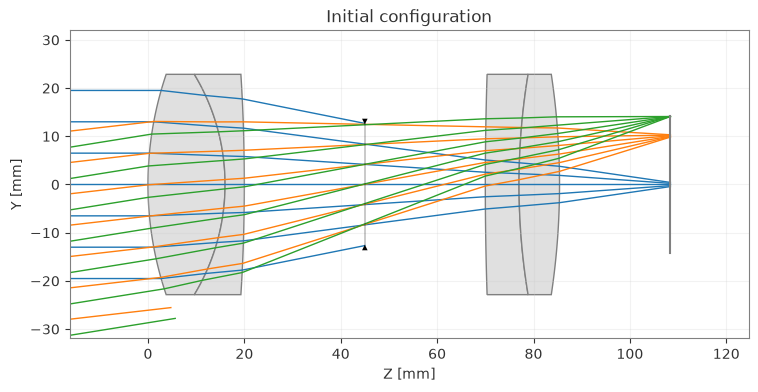

In [5]:
lens.info()
lens.draw(num_rays=7, title="Initial configuration")


## 3. Optimize the inter-group spacing

Only the on-axis RMS spot size is included in the merit function. This prioritizes a centrally positioned subject while intentionally leaving the off-axis aberrations uncorrected. Those residual aberrations are part of the intended visual character and are not interpreted as an optimization failure.

Both variables are given positive, mechanically plausible bounds to prevent the optimizer from exploring nonphysical group separations.


╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │             0.00155057 │             99.77 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ rms spot size  │        0 │              │              │        1 │             1 │   0.016 │   0.016 │          15.54 │
│  1 │ rms spot size  │        0 │              │              │        1 │             1 │   0.023 │   0.023 │          34.75 │
│  2 │ rms spot size  │        0 │              │              │        1 │             1 │   0

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'After inter-group spacing optimization'}, xlabel='Z [mm]', ylabel='Y [mm]'>)

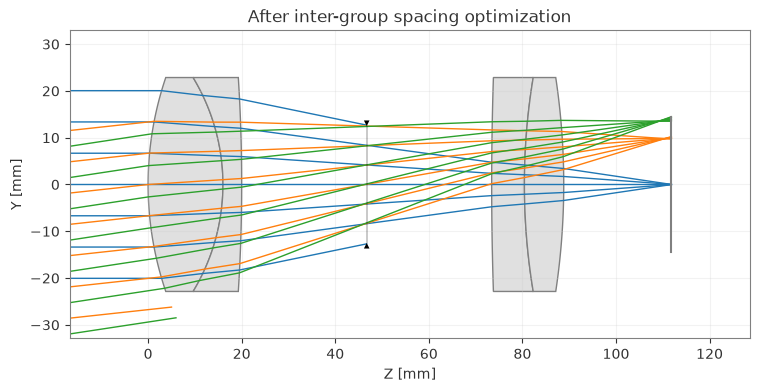

In [6]:
problem = optimization.OptimizationProblem()

for wavelength in lens.wavelengths.get_wavelengths():
    problem.add_operand(
        operand_type="rms_spot_size",
        target=0,
        weight=1,
        input_data={
            "optic": lens,
            "Hx": 0,
            "Hy": 0,
            "num_rays": 6,
            "wavelength": wavelength,
            "distribution": "hexapolar",
            "surface_number": INITIAL_IMAGE_SURFACE,
        },
    )

problem.add_variable(
    lens,
    "thickness",
    surface_number=FRONT_GROUP_REAR_SURFACE,
    min_val=25.0,
    max_val=35.0,
)
problem.add_variable(
    lens,
    "thickness",
    surface_number=STOP_SURFACE,
    min_val=25.0,
    max_val=35.0,
)

optimizer = optimization.OptimizerGeneric(problem)
result = optimizer.optimize()
problem.info()
lens.updater.update()
lens.draw(num_rays=7, title="After inter-group spacing optimization")


### Paraxial properties

The values below are paraxial quantities reported by Optiland. The paraxial image-space f-number should not automatically be interpreted as the finite-conjugate working f-number of the assembled lens. At close focus, pupil magnification, image-space cone angle, and mechanical vignetting can all affect the effective exposure and depth of field.


In [7]:
print(f"Paraxial image-space f-number: {lens.paraxial.FNO()}")
print("Paraxial entrance-pupil diameter [mm]: "f"{lens.paraxial.EPD()}")


Paraxial image-space f-number: [2.28644966]
Paraxial entrance-pupil diameter [mm]: [40.10874677]


## 4. Integrate the mechanical components

The optical model is now extended with the SM2-to-M42 interface, the M42-to-Sony-E adapter, the Sony E-mount flange focal distance, and the APS-C image-plane aperture. The clear apertures of these components are included so that mechanical clipping is represented during ray tracing.


╒════╤═══════════════╤════════════════════════════════════╤══════════╤═════════════╤════════════╤═════════╤═════════════════╕
│    │ Type          │ Comment                            │   Radius │   Thickness │ Material   │   Conic │   Semi-aperture │
╞════╪═══════════════╪════════════════════════════════════╪══════════╪═════════════╪════════════╪═════════╪═════════════════╡
│  0 │ Planar        │                                    │  inf     │       inf   │ Air        │       0 │         39.0281 │
│  1 │ Standard      │                                    │   71.12  │        16   │ N-BAF10    │       0 │         22.86   │
│  2 │ Standard      │                                    │  -44.17  │         4   │ SF10       │       0 │         22.86   │
│  3 │ Standard      │                                    │ -363.1   │        37   │ Air        │       0 │         22.86   │
│  4 │ Stop - Planar │ SM2 iris                           │  inf     │        14   │ Air        │       0 │         12

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Layout with mechanical components'}, xlabel='Z [mm]', ylabel='Y [mm]'>)

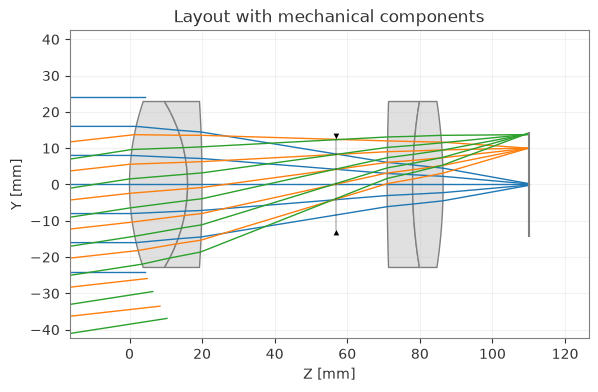

In [8]:
# Add the M42-to-E adapter and the flange focal distance.
M42_E_ADAPTER_SURFACE = 8
E_MOUNT_SURFACE = 9
FINAL_IMAGE_SURFACE = 10

lens.surfaces.add(
    index=M42_E_ADAPTER_SURFACE,
    thickness=1.0,
    comment="M42-to-Sony-E adapter",
)
lens.surfaces.add(
    index=E_MOUNT_SURFACE,
    thickness=18.0,
    comment="Sony E-mount flange focal distance",
)

# Mechanical distances [mm].
lens.updater.set_thickness(4.6, REAR_GROUP_REAR_SURFACE)
lens.updater.set_thickness(1.0, M42_E_ADAPTER_SURFACE)
lens.updater.set_thickness(18.0, E_MOUNT_SURFACE)
lens.updater.set_thickness(37.0, FRONT_GROUP_REAR_SURFACE)
lens.updater.set_thickness(14.0, STOP_SURFACE)

# Mechanical clear semi-apertures [mm].
lens.surfaces[REAR_GROUP_REAR_SURFACE].set_semi_aperture(19.05)
lens.surfaces[M42_E_ADAPTER_SURFACE].set_semi_aperture(20.65)
lens.surfaces[E_MOUNT_SURFACE].set_semi_aperture(23.05)
lens.surfaces[FINAL_IMAGE_SURFACE].set_semi_aperture(14.1)

lens.info()
lens.draw(
    num_rays=7,
    title="Layout with mechanical components",
)


## 5. Refocus within the helicoid travel

The final optimization varies only the front-group-to-stop spacing. Its bounds, 37–51 mm, correspond to the available helicoid travel. The same on-axis-only design philosophy is retained.


╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │             0.00940017 │           96.6875 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ rms spot size  │        0 │              │              │        1 │             1 │   0.082 │   0.082 │          70.91 │
│  1 │ rms spot size  │        0 │              │              │        1 │             1 │   0.036 │   0.036 │          13.61 │
│  2 │ rms spot size  │        0 │              │              │        1 │             1 │   0

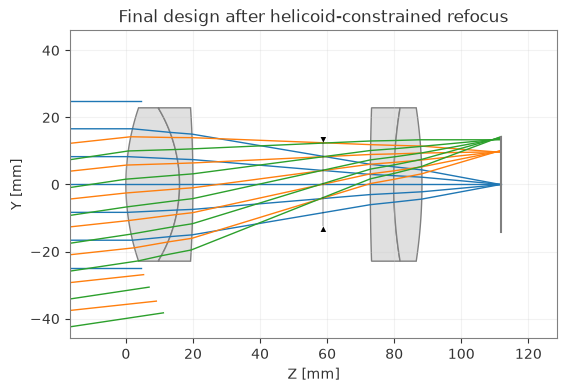

In [9]:
problem = optimization.OptimizationProblem()

for wavelength in lens.wavelengths.get_wavelengths():
    problem.add_operand(
        operand_type="rms_spot_size",
        target=0,
        weight=1,
        input_data={
            "optic": lens,
            "Hx": 0,
            "Hy": 0,
            "num_rays": 6,
            "wavelength": wavelength,
            "distribution": "hexapolar",
            "surface_number": FINAL_IMAGE_SURFACE,
        },
    )

problem.add_variable(
    lens,
    "thickness",
    surface_number=FRONT_GROUP_REAR_SURFACE,
    min_val=37.0,
    max_val=51.0,
)

optimizer = optimization.OptimizerGeneric(problem)
result = optimizer.optimize()
problem.info()
lens.updater.update()

lens.draw(
    num_rays=7,
    title="Final design after helicoid-constrained refocus",
)

save_optiland_file(lens, "DIY_Portrait_Lens_Design.json")


In [10]:
print(f"Paraxial image-space f-number: {lens.paraxial.FNO()}")
print("Paraxial entrance-pupil diameter [mm]: "f"{lens.paraxial.EPD()}")


Paraxial image-space f-number: [1.8372261]
Paraxial entrance-pupil diameter [mm]: [49.83028431]


## 6. Through-focus image quality

A through-focus spot diagram shows whether the merit-function minimum corresponds closely to the visually useful focus and illustrates how rapidly the image degrades away from it.


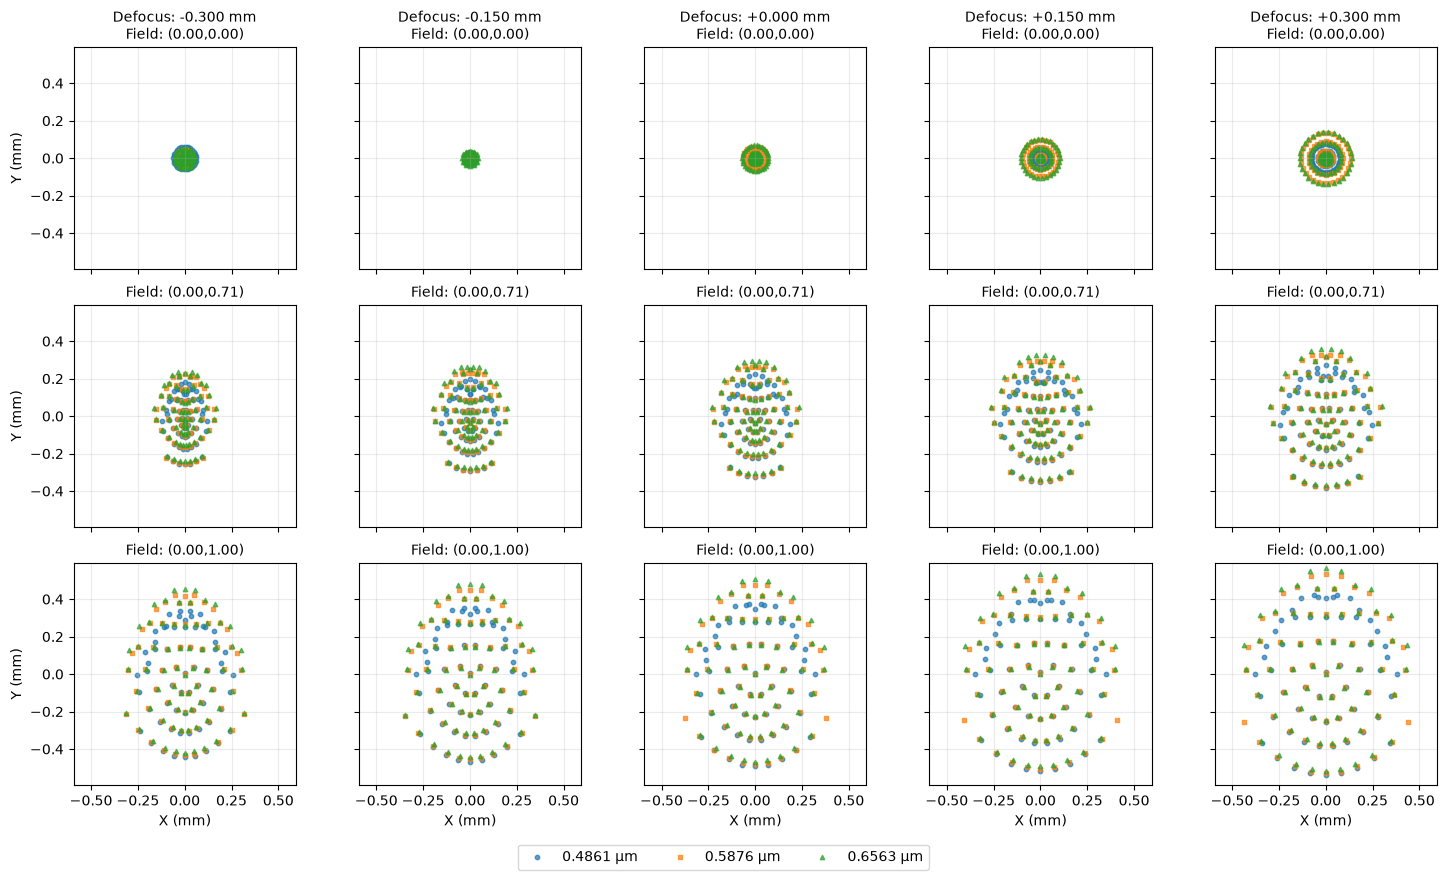

(<Figure size 1500x900 with 15 Axes>,
 [<Axes: title={'center': 'Defocus: -0.300 mm\nField: (0.00,0.00)'}, ylabel='Y (mm)'>,
  <Axes: title={'center': 'Defocus: -0.150 mm\nField: (0.00,0.00)'}>,
  <Axes: title={'center': 'Defocus: +0.000 mm\nField: (0.00,0.00)'}>,
  <Axes: title={'center': 'Defocus: +0.150 mm\nField: (0.00,0.00)'}>,
  <Axes: title={'center': 'Defocus: +0.300 mm\nField: (0.00,0.00)'}>,
  <Axes: title={'center': 'Field: (0.00,0.71)'}, ylabel='Y (mm)'>,
  <Axes: title={'center': 'Field: (0.00,0.71)'}>,
  <Axes: title={'center': 'Field: (0.00,0.71)'}>,
  <Axes: title={'center': 'Field: (0.00,0.71)'}>,
  <Axes: title={'center': 'Field: (0.00,0.71)'}>,
  <Axes: title={'center': 'Field: (0.00,1.00)'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Field: (0.00,1.00)'}, xlabel='X (mm)'>,
  <Axes: title={'center': 'Field: (0.00,1.00)'}, xlabel='X (mm)'>,
  <Axes: title={'center': 'Field: (0.00,1.00)'}, xlabel='X (mm)'>,
  <Axes: title={'center': 'Field: (0.00,1.0

In [11]:
tf_spot = ThroughFocusSpotDiagram(
    lens,
    num_steps=5,
    delta_focus=0.15,
    fields="all",
    wavelengths="all",
)
tf_spot.view()


### FFT MTF near the selected focus

The following sweep evaluates a small range of front-group-to-stop distances around the through-focus estimate. Each plot uses all fields and wavelengths configured in the optical system.


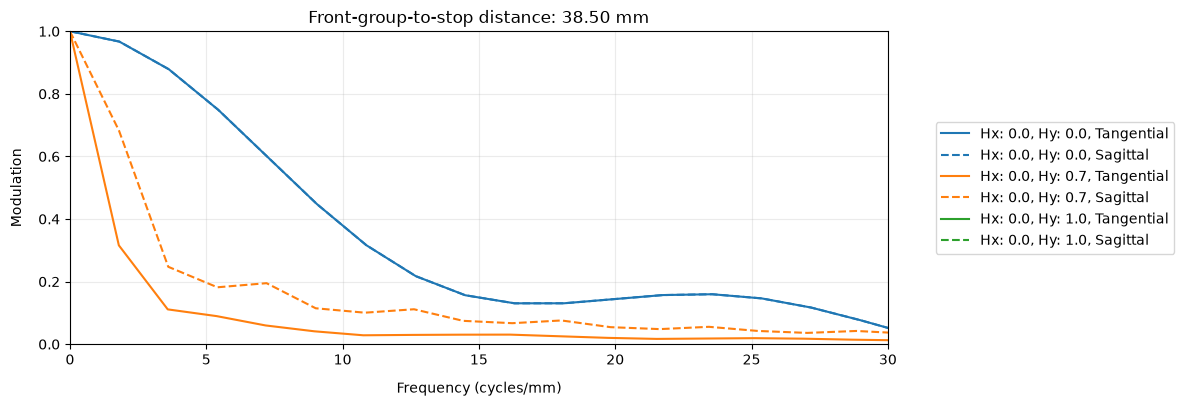

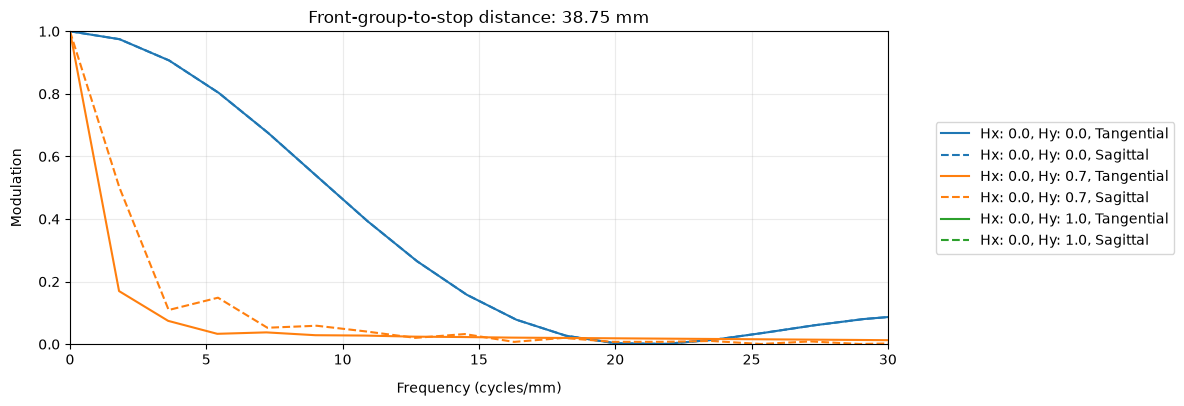

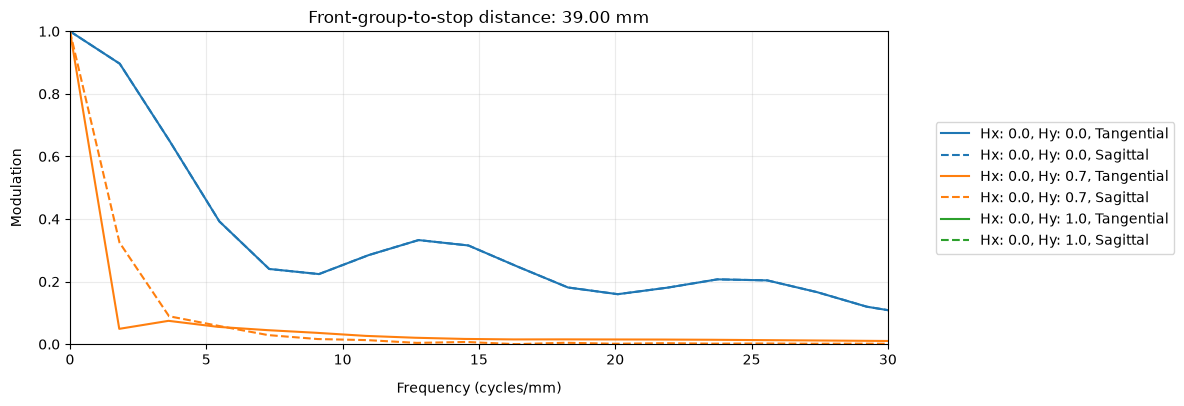

In [12]:
focus_positions = be.linspace(38.5, 39.0, 3)

for spacing in focus_positions:
    spacing = float(spacing)
    lens.updater.set_thickness(spacing, FRONT_GROUP_REAR_SURFACE)

    fft_mtf = FFTMTF(
        lens,
        max_freq=30,
        num_rays=512,
        grid_size=512,
    )
    fft_mtf.view()
    plt.title(f"Front-group-to-stop distance: {spacing:.2f} mm")
    plt.show()


## Field Curvature variation

To visualize how the field curvature changes while focussing for various object distances, the field curvature plots are generated for the entire Helicoid movement range.

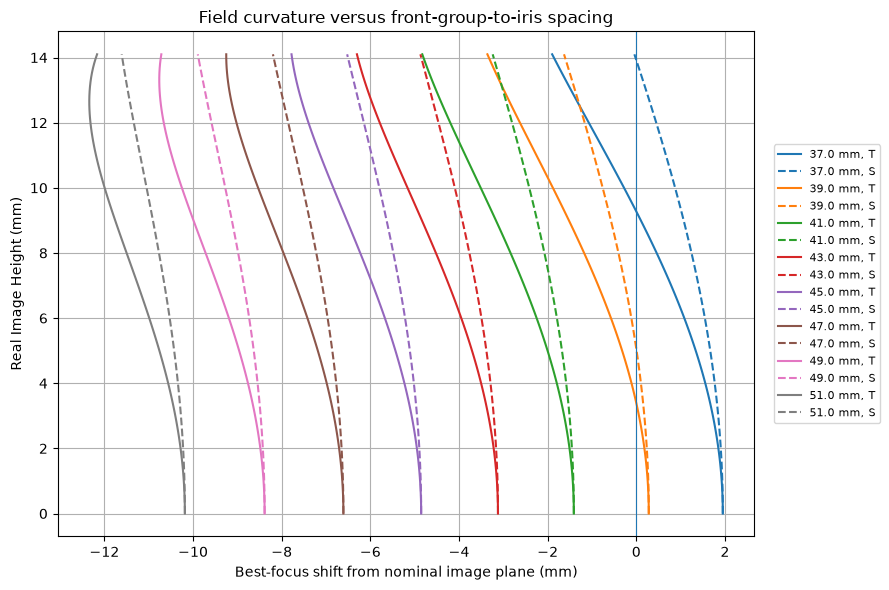

In [13]:


FRONT_REAR_SURFACE = 3

# Example front-group-to-iris spacings in mm
helicoid_spacings = be.linspace(37.0, 51.0, 8)

# Save the starting configuration so it can be restored afterwards.
original_spacing = float(
    be.asarray(lens.surfaces[FRONT_REAR_SURFACE].thickness).squeeze()
)

fig, ax = plt.subplots(figsize=(9, 6))

results = {}

try:
    for spacing in helicoid_spacings:
        # Move the front group relative to the fixed iris/rear group.
        lens.updater.set_thickness(
            float(spacing),
            FRONT_REAR_SURFACE,
        )

        field_curvature = analysis.FieldCurvature(
            lens,
            wavelengths=[lens.primary_wavelength],
            num_points=101,
        )

    
        tangential = be.to_numpy(field_curvature.data[0][0])
        sagittal = be.to_numpy(field_curvature.data[0][1])

        # FieldCurvature samples from 0 to max_field.
        field = be.linspace(
            0.0,
            float(lens.fields.max_field),
            len(tangential),
        )

        results[float(spacing)] = {
            "field": field,
            "tangential": tangential,
            "sagittal": sagittal,
        }

        # Same colour for one helicoid position:
        # solid = tangential, dashed = sagittal
        line, = ax.plot(
            tangential,
            field,
            label=f"{spacing:.1f} mm, T",
        )

        ax.plot(
            sagittal,
            field,
            linestyle="--",
            color=line.get_color(),
            label=f"{spacing:.1f} mm, S",
        )

finally:
    lens.updater.set_thickness(
        original_spacing,
        FRONT_REAR_SURFACE,
    )

ax.axvline(0.0, linewidth=0.8)
ax.set_xlabel("Best-focus shift from nominal image plane (mm)")
ax.set_ylabel("Real Image Height (mm)")
ax.set_title("Field curvature versus front-group-to-iris spacing")
ax.grid(True)
ax.legend(
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    fontsize=8,
)
fig.tight_layout()
plt.show()

## 7. Assembly tolerancing

The catalog elements themselves are assumed to be better controlled than the DIY assembly. The dominant uncertainties considered here are therefore lens tilt and decenter caused by placing the achromats in threaded tubes without precision centering or clocking features.

The perturbations below are **normal distributions**. Their `scale` values are standard deviations:

- tilt: 3σ = 0.02 radians (1 degree)
- decenter: 3σ = 0.15 mm

The helicoid spacing is used as a compensator, representing refocusing after assembly. Of particular interest are the variation of coma and astigmatism with tilt and decenter. These help us understand how the mechanical perturbations cause asymmetric aberrations.

At the time of writing this report, Optiland does not directly support tilt and decenter of entire groups. We hence will need to workaround this, by defining the system with coordinate breaks instead of thicknesses. This helps provides the possibility to tilt and decenter groups of surfaces. In this case, the tilt and decenter will be assumed to be about the geometrical center of the lens. 

In [14]:
num_systems = 100

front_rx = be.random.normal(loc=0, scale=be.deg2rad(1/3), size=num_systems)
front_ry = be.random.normal(loc=0, scale=be.deg2rad(1/3), size=num_systems)
front_dx = be.random.normal(loc=0, scale=0.05, size=num_systems)
front_dy = be.random.normal(loc=0, scale=0.05, size=num_systems)

rear_rx = be.random.normal(loc=0, scale=be.deg2rad(1/3), size=num_systems)
rear_ry = be.random.normal(loc=0, scale=be.deg2rad(1/3), size=num_systems)
rear_dx = be.random.normal(loc=0, scale=0.05, size=num_systems)
rear_dy = be.random.normal(loc=0, scale=0.05, size=num_systems)



class LensConfigurable(optic.Optic):

    def __init__(self, rx,ry,dx,dy):
        super().__init__()
        self.rx=rx
        self.ry=ry
        self.dx=dx
        self.dy=dy

       
        # add surfaces
        self.surfaces.add(index=0, radius=be.inf, thickness=be.inf)
        self.surfaces.add(index=1, radius=71.12, thickness=16, material='N-BAF10', semi_aperture=22.86,dx=dx[0],dy=dy[0],ry=ry[0],rx=rx[0] )
        
        self.surfaces.add(index=2, radius=-44.17, thickness=4, material="SF10",semi_aperture=22.86,dx=dx[0],dy=dy[0],ry=ry[0],rx=rx[0])
        self.surfaces.add(index=3, radius=-363.1, thickness=38.87, semi_aperture=22.86,dx=dx[0],dy=dy[0],ry=ry[0],rx=rx[0])
        self.surfaces.add(index=4, radius=be.inf, thickness=14,semi_aperture=12.5, is_stop=True)
        self.surfaces.add(index=5, radius=706.754, thickness=7,semi_aperture=22.86, material="N-SF2",dx=dx[1],dy=dy[1],ry=ry[1],rx=rx[1])
        self.surfaces.add(index=6, radius=139.918, thickness=8.4,semi_aperture=22.86,material="N-BK7",dx=dx[1],dy=dy[1],ry=ry[1],rx=rx[1])
        self.surfaces.add(index=7, radius=-153.739, thickness=4.6,semi_aperture=22.86,dx=dx[1],dy=dy[1],ry=ry[1],rx=rx[1])
        self.surfaces.add(index=8, radius=be.inf, thickness=1,semi_aperture=14.05)
        self.surfaces.add(index=9, radius=be.inf, thickness=18,semi_aperture=14.02)
        self.surfaces.add(index=10,semi_aperture=14.3)
        
        # add aperture
        self.set_aperture('float_by_stop_size',25)

        # add field
        self.fields.set_type(field_type="real_image_height")
        self.fields.add(y=0)
        self.fields.add(y=10)
        self.fields.add(y=14.2)

        # add wavelength
        self.wavelengths.add(value=0.5876, is_primary=True)

In [15]:
rms_spot_radius = []
tot_ast, tot_coma = [], []

for k in range(num_systems):
    # generate a random singlet
    lens = LensConfigurable([front_rx[k],rear_rx[k]],[front_ry[k],rear_ry[k]],[front_dx[k],rear_dx[k]],[front_dy[k],rear_dy[k]])
    spot = analysis.SpotDiagram(lens)
    value = spot.rms_spot_radius()[0][0]
    rms_spot_radius.append(value)

    zernike = wavefront.ZernikeOPD(lens, (0, 0), 0.5876, zernike_type="standard", num_terms=9)
    tot_ast.append(be.sqrt(zernike.coeffs[3]**2+zernike.coeffs[5]**2))
    tot_coma.append(be.sqrt(zernike.coeffs[7]**2+zernike.coeffs[8]**2))
    


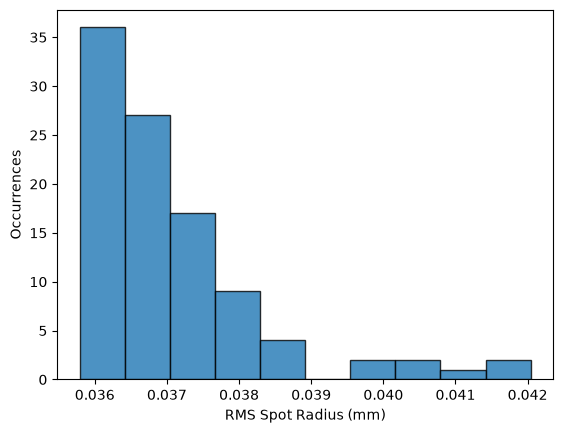

In [16]:
plt.hist(rms_spot_radius, color="C0", edgecolor="k", alpha=0.8)
plt.xlabel("RMS Spot Radius (mm)")
plt.ylabel("Occurrences")
plt.show()

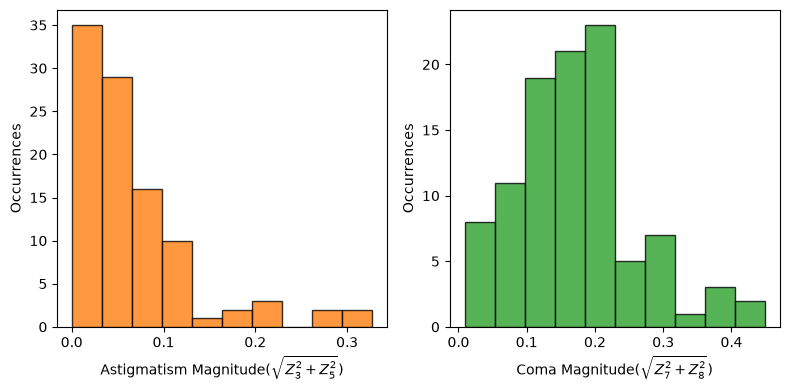

In [17]:
plt.figure(figsize=(8,4))
plt.subplot(121)
plt.hist(tot_ast, color="C1", edgecolor="k", alpha=0.8)
plt.xlabel("Astigmatism Magnitude($\sqrt{Z_{3}^2+Z_{5}^2}$)")
plt.ylabel("Occurrences")
plt.subplot(122)
plt.hist(tot_coma, color="C2", edgecolor="k", alpha=0.8)
plt.xlabel("Coma Magnitude($\sqrt{Z_{7}^2+Z_{8}^2}$)")
plt.ylabel("Occurrences")
plt.tight_layout()
plt.show()

## Calculating the sensitivities and their correlations

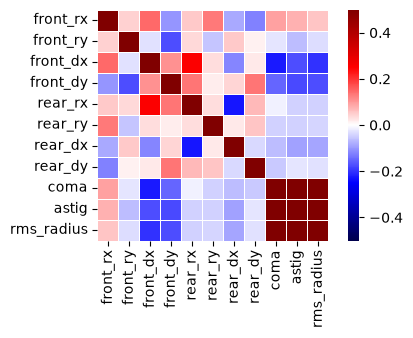

In [18]:
import pandas as pd
import seaborn as sns
df = pd.DataFrame({
    "front_rx": front_rx,
    "front_ry": front_ry,
    "front_dx": front_dx,
    "front_dy": front_dy,
    "rear_rx": rear_rx,
    "rear_ry": rear_ry,
    "rear_dx": rear_dx,
    "rear_dy": rear_dy,
    "coma": tot_coma,
    "astig": tot_ast,
    "rms_radius": rms_spot_radius,
})

corr = df.corr()

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(5, 3))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, cmap='seismic', vmin=-0.5, vmax=0.5, center=0, square=True, linewidths=0.5)
plt.show()

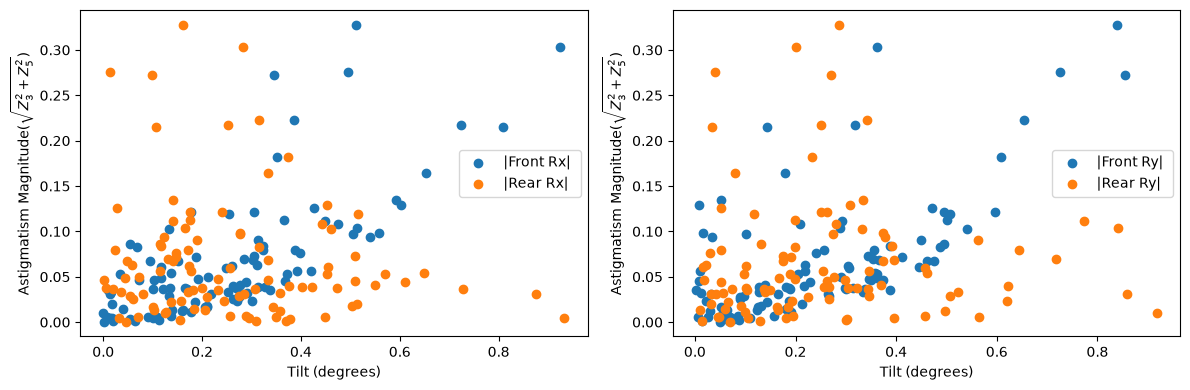

In [19]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(be.rad2deg(be.abs(front_rx)), tot_ast,label='|Front Rx| ')
plt.scatter(be.rad2deg(be.abs(rear_rx)), tot_ast, label='|Rear Rx|')
plt.xlabel('Tilt (degrees)')
plt.ylabel("Astigmatism Magnitude($\sqrt{Z_{3}^2+Z_{5}^2}$)")
plt.legend()

plt.subplot(122)
plt.scatter(be.rad2deg(be.abs(front_ry)), tot_ast,label='|Front Ry| ')
plt.scatter(be.rad2deg(be.abs(rear_ry)), tot_ast, label='|Rear Ry|')
plt.xlabel('Tilt (degrees)')
plt.ylabel("Astigmatism Magnitude($\sqrt{Z_{3}^2+Z_{5}^2}$)")
plt.legend()
plt.tight_layout()

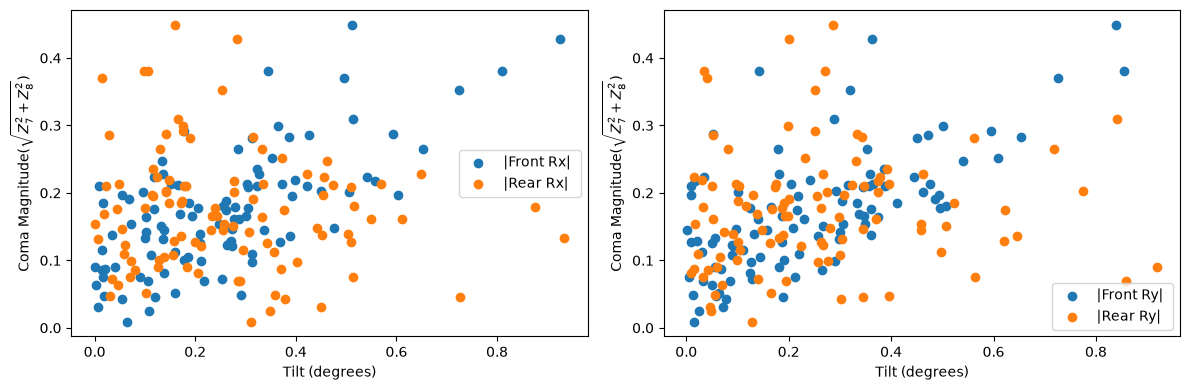

In [20]:
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.scatter(be.rad2deg(be.abs(front_rx)), tot_coma,label='|Front Rx| ')
plt.scatter(be.rad2deg(be.abs(rear_rx)), tot_coma, label='|Rear Rx|')
plt.xlabel('Tilt (degrees)')
plt.ylabel("Coma Magnitude($\sqrt{Z_{7}^2+Z_{8}^2}$)")
plt.legend()

plt.subplot(122)
plt.scatter(be.rad2deg(be.abs(front_ry)), tot_coma,label='|Front Ry| ')
plt.scatter(be.rad2deg(be.abs(rear_ry)), tot_coma, label='|Rear Ry|')
plt.xlabel('Tilt (degrees)')
plt.ylabel("Coma Magnitude($\sqrt{Z_{7}^2+Z_{8}^2}$)")
plt.legend()
plt.tight_layout()

## 8. Summary

This notebook develops a mechanically constrained portrait lens from two catalog achromats rather than treating the optical prescription in isolation. The central field is intentionally optimized while off-axis aberrations remain largely unconstrained, supporting the desired pictorial rendering. The final model includes the real focusing range, adapters, mount opening, flange focal distance, sensor size, and a first-order estimate of assembly sensitivity.